<a href="https://colab.research.google.com/github/alkalijosiah289-oss/CAR-PRICE-PREDICTION/blob/main/CAR_PRICE_PREDICTION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CAR PRICE PREDICTION

In [ ]:
# import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

In [ ]:
#loading the dataset
data = pd.read_csv('/content/Car_data_jtrjuw (1).csv')
# Re-reading data here to ensure a clean state for subsequent preprocessing steps.

In [ ]:
data.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [ ]:
data.tail()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
296,city,2016,9.50,11.6,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.9,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.0,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.5,9000,Diesel,Dealer,Manual,0
300,brio,2016,5.30,5.9,5464,Petrol,Dealer,Manual,0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [ ]:
data.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [ ]:
data.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0


In [ ]:
data.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner'],
      dtype='object')

In [ ]:
# 3. Feature Scaling
scaler = StandardScaler()
# Identify numerical columns for scaling, excluding the target variable 'Selling_Price'
numerical_cols = ['Present_Price', 'Kms_Driven', 'No_of_years']
data[numerical_cols] = scaler.fit_transform(data[numerical_cols])
display(data.head())

,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,No_of_years
0,3.35,-0.236215,-0.256224,Petrol,Dealer,Manual,-0.128897
1,4.75,0.221505,0.155911,Diesel,Dealer,Manual,0.217514
2,7.25,0.257427,-0.773969,Petrol,Dealer,Manual,-1.168129
3,2.85,-0.403079,-0.817758,Petrol,Dealer,Manual,0.910335
4,4.60,-0.087890,0.141743,Diesel,Dealer,Manual,-0.128897


In [ ]:
# 2. One-Hot Encode Categorical Features
# Select categorical columns to encode
categorical_cols = ['Fuel_Type', 'Seller_Type', 'Transmission']

# Apply one-hot encoding
data = pd.get_dummies(data, columns=categorical_cols, drop_first=True)

display(data.head())

In [ ]:
X = data.drop('Selling_Price', axis=1)
y = data['Selling_Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (240, 7)
Shape of X_test: (61, 7)
Shape of y_train: (240,)
Shape of y_test: (61,)


In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.2f}")

Mean Squared Error: 3.36
R-squared: 0.85


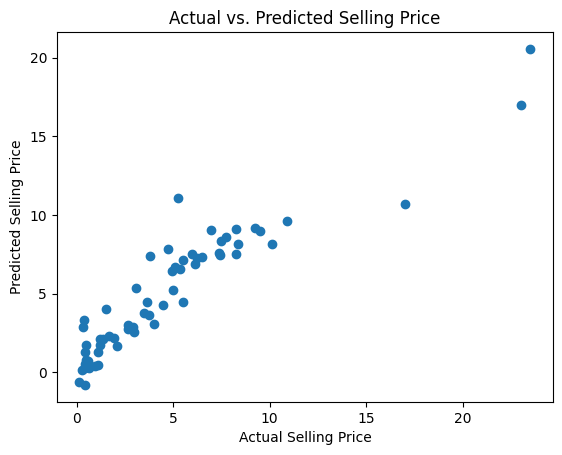

In [ ]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs. Predicted Selling Price")
plt.show()

In [ ]:
# 2. One-Hot Encode Categorical Features
# Select categorical columns to encode
categorical_cols = ['Fuel_Type', 'Seller_Type', 'Transmission']

# Apply one-hot encoding
data = pd.get_dummies(data, columns=categorical_cols, drop_first=True)

display(data.head())

,Selling_Price,Present_Price,Kms_Driven,No_of_years,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,3.35,-0.236215,-0.256224,-0.128897,False,True,False,True
1,4.75,0.221505,0.155911,0.217514,True,False,False,True
2,7.25,0.257427,-0.773969,-1.168129,False,True,False,True
3,2.85,-0.403079,-0.817758,0.910335,False,True,False,True
4,4.60,-0.087890,0.141743,-0.128897,True,False,False,True


In [31]:
# Select categorical columns to encode
categorical_cols = ['Fuel_Type', 'Seller_Type', 'Transmission']

# Apply one-hot encoding
data = pd.get_dummies(data, columns=categorical_cols, drop_first=True)

display(data.head())

,Selling_Price,Present_Price,Kms_Driven,No_of_years,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,3.35,5.59,27000,6,False,True,False,True
1,4.75,9.54,43000,7,True,False,False,True
2,7.25,9.85,6900,3,False,True,False,True
3,2.85,4.15,5200,9,False,True,False,True
4,4.60,6.87,42450,6,True,False,False,True
